## Validation of model TKA_SHA_JGA_Mo_240503_3 with Gao data

In [3]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import pandas as pd
from ICIW_Plots import cyclers as ICIW_cyclers
import matplotlib

In [4]:
## import the model
from TKA_SHA_JGA_Mo_240503_3 import calc_eq_methanation

In [5]:
## Test the model by verification with data from Gao

## validation (Gao 2012, https://doi.org/10.1039/C2RA00632D)
p = np.array([1*1.01325, 2])*1e5 # p in Pa
T = np.linspace(200 + 273.15, 800 + 273.15, 100) # T in K
type = 'real gas' # choose type of gas from 'ideal gas' and 'real gas'

# Parameter
n0 = np.empty(7)
n0[0] = 0.2       # initial mole fraction of CO2
n0[1] = 0.8-7e-20 # initial mole fraction of H2
n0[2] = 1e-20     # initial mole fraction of CH4
n0[3] = 1e-20     # initial mole fraction of H2O
n0[4] = 1e-20     # initial mole fraction of CO
n0[5] = 1e-20     # initial mole fraction of C
n0[6] = 1e-20     # initial mole fraction of Inert

In [6]:
## EQ calculation
n_eq = np.empty((len(T),len(n0)))
x_eq = np.empty((len(T),len(n0)))
success = []
not_converged = 0
for TT in range(len(T)):
    n_eq_temp,success_temp = calc_eq_methanation(T[TT],p[0],n0,type=type)   # guess=guess  
    if success_temp:
        n_eq[TT,:] = n_eq_temp
        x_eq[TT,:] = n_eq_temp/np.sum(n_eq_temp)
    else:  
        n_eq[TT,:] = np.nan
        x_eq[TT,:] = np.nan
    success.append(success_temp)
    if success_temp == False:
        not_converged +=1
print(f'\nConverged calculations: {(len(T)-not_converged)/len(T):.0%} ({len(T) - not_converged}/{len(T)})')



Converged calculations: 99% (99/100)


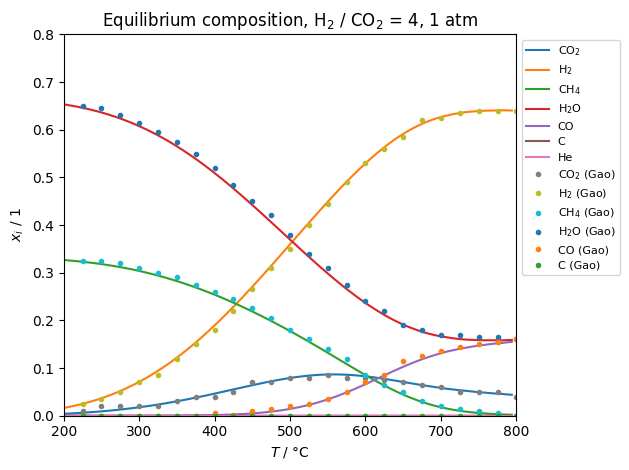

In [7]:
## data import - validation data
csv_data_Gao = pd.read_csv(r'data_Gao_CO2.csv',  # read csv file
                            sep = ';')
## convert read data into numpy array
data_Gao         = csv_data_Gao.to_numpy()

T_CO2_Gao        = data_Gao[:, 0]
x_CO2_Gao        = data_Gao[:, 1:7]

# plt.style.use('ICIWstyle')
font = {'size': 10}
matplotlib.rc('font', **font)

## CO2 methanation
fig, axs = plt.subplots()

axs.plot(T - 273.15,  x_eq[:, 0],     '-',                 label = 'CO$_2$')
axs.plot(T - 273.15,  x_eq[:, 1],     '-',                 label = 'H$_2$')
axs.plot(T - 273.15,  x_eq[:, 2],     '-',                 label = 'CH$_4$')
axs.plot(T - 273.15,  x_eq[:, 3],     '-',                 label = 'H$_2$O')
axs.plot(T - 273.15,  x_eq[:, 4],     '-',                 label = 'CO')
axs.plot(T - 273.15,  x_eq[:, 5],     '-',                 label = 'C')
axs.plot(T - 273.15,  x_eq[:, 6],     '-',                 label = 'He')
#axs.plot(T - 273.15,  x[:, 7],     '-',                 label = 'Ar')
#axs.plot(T - 273.15,  x[:, 8],     '-',                 label = 'N$_2$')
axs.plot(T_CO2_Gao,   x_CO2_Gao[:, 0], 'o', markersize = 3, label = 'CO$_2$ (Gao)')
axs.plot(T_CO2_Gao,   x_CO2_Gao[:, 1], 'o', markersize = 3, label = 'H$_2$ (Gao)')
axs.plot(T_CO2_Gao,   x_CO2_Gao[:, 2], 'o', markersize = 3, label = 'CH$_4$ (Gao)')
axs.plot(T_CO2_Gao,   x_CO2_Gao[:, 3], 'o', markersize = 3, label = 'H$_2$O (Gao)')
axs.plot(T_CO2_Gao,   x_CO2_Gao[:, 4], 'o', markersize = 3, label = 'CO (Gao)')
axs.plot(T_CO2_Gao,   x_CO2_Gao[:, 5], 'o', markersize = 3, label = 'C (Gao)')
axs.set_xlabel('$T$ / °C')
axs.set_ylabel('$x_i$ / 1')
axs.set_title('Equilibrium composition, H$_2$ / CO$_2$ = 4, 1 atm')
axs.set_ylim(0, 0.8)
axs.set_xlim(200, 800)
plt.legend(bbox_to_anchor=(1,1), loc="upper left", fontsize = 8)
plt.tight_layout()
plt.show()